In [1]:
# Cell 1 - Install library
!pip install scikit-learn tensorflow matplotlib pandas numpy

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------------- ------------------- 4.2/8.0 MB 28.6 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 23.2 MB/s  0:00:00
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 6.8/351.2 MB 33.4 MB/s eta 0:00:11
   - -------------------------------------- 14.7/351.2 MB 35.9 MB/s eta 0:0

In [5]:
# Cell 2 - Import & Load Dataset Wine UCI
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Nama kolom Wine UCI
col_names = [
    'Class',
    'Alcohol', 'Malic_Acid', 'Ash', 'Alcalinity_of_Ash',
    'Magnesium', 'Total_Phenols', 'Flavanoids',
    'Nonflavanoid_Phenols', 'Proanthocyanins',
    'Color_Intensity', 'Hue', 'OD280_OD315', 'Proline'
]

df = pd.read_csv('wine.data', header=None, names=col_names)

print(df.head())
print(df.info())
print(df['Class'].value_counts())  # cek distribusi kelas

   Class  Alcohol  Malic_Acid   Ash  Alcalinity_of_Ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total_Phenols  Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color_Intensity   Hue  OD280_OD315  Proline  
0             5.64  1.04         3.92     1065  
1             4.38  1.05         3.40     1050  
2          

In [6]:
# Cell 3 - Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Pisah fitur dan target
X = df.drop('Class', axis=1)   # ✅ sudah bener, ganti 'kolom_target' -> 'Class'
y = df['Class']

# Encode label (1,2,3 -> 0,1,2) supaya cocok sama neural network
le = LabelEncoder()
y = le.fit_transform(y)

# Normalisasi fitur
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Jumlah kelas: {len(set(y))}")  # harusnya 3

Train size : (142, 13)
Test size  : (36, 13)
Jumlah kelas: 3


In [7]:
# Cell 4 - Algoritma Pembanding
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree"      : DecisionTreeClassifier(),
    "Random Forest"      : RandomForestClassifier(),
    "SVM"                : SVC()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = round(acc, 4)
    print(f"{name:25s}: {acc:.4f}")

Logistic Regression      : 1.0000
Decision Tree            : 0.9444
Random Forest            : 1.0000
SVM                      : 1.0000


In [8]:
# Cell 5 - Neural Network
import tensorflow as tf
from tensorflow import keras

n_features = X_train.shape[1]  # 13 fitur
n_classes  = len(set(y))       # 3 kelas

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(n_features,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

_, acc_nn = model.evaluate(X_test, y_test, verbose=0)
results["Neural Network"] = round(float(acc_nn), 4)
print(f"\nNeural Network Accuracy: {acc_nn:.4f}")

d:\Semester 6\SC\tugas 2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.3543 - loss: 1.1816 - val_accuracy: 0.7333 - val_loss: 0.9082
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5591 - loss: 0.9723 - val_accuracy: 0.8000 - val_loss: 0.7616
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6693 - loss: 0.8032 - val_accuracy: 0.8667 - val_loss: 0.6394
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8898 - loss: 0.6592 - val_accuracy: 0.9333 - val_loss: 0.5388
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9606 - loss: 0.5424 - val_accuracy: 0.9333 - val_loss: 0.4578
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9685 - loss: 0.4476 - val_accuracy: 0.9333 - val_loss: 0.3932
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9685 - loss: 0.3687 - val_accuracy: 0.9333 - val_loss: 0.3441
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9764 - loss: 0.3029 - val_accuracy: 0.9333 - val_loss

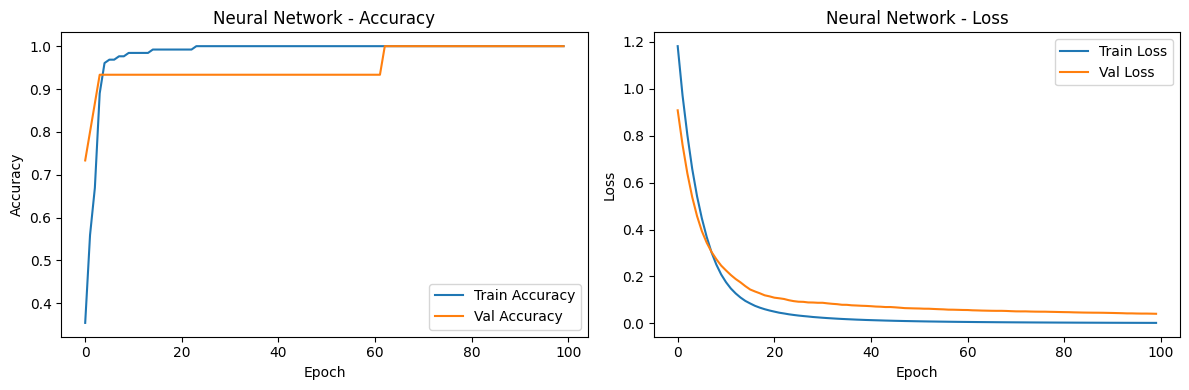

In [9]:
# Cell 6 - Plot Training History Neural Network
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Neural Network - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Neural Network - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Model                       Accuracy
Logistic Regression           1.0000
Decision Tree                 0.9444
Random Forest                 1.0000
SVM                           1.0000
Neural Network                1.0000


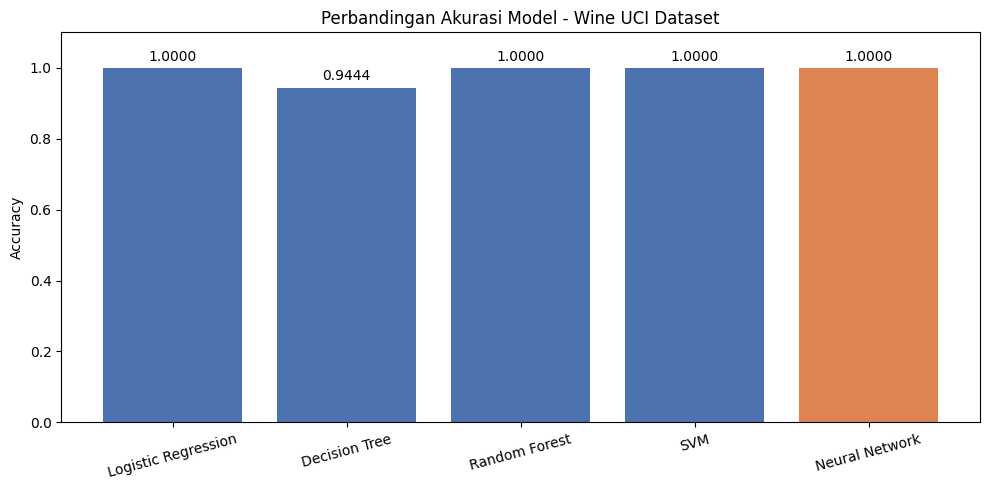

In [10]:
# Cell 7 - Perbandingan Akurasi Semua Model
print("=" * 40)
print(f"{'Model':<25} {'Accuracy':>10}")
print("=" * 40)
for name, acc in results.items():
    print(f"{name:<25} {acc:>10.4f}")
print("=" * 40)

# Bar Chart
plt.figure(figsize=(10, 5))
colors = ['#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#DD8452']
plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Accuracy')
plt.title('Perbandingan Akurasi Model - Wine UCI Dataset')
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.02, f"{acc:.4f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()